# Notebook 2: Preprocessing & Feature Reduction — Liver Cancer Gene Expression

**Input file:**  `liver_clean.csv`  
**Output files:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

> **Important:** All preprocessing steps (scaling, feature selection) are **fit on the training set only** and then applied to the test set. This prevents data leakage.

---

**What this notebook does:**
1. Loads the cleaned dataset
2. Separates features (X) and target (y), then performs a stratified train/test split
3. **Step 1 — Remove zero-variance features:** drop probes with identical values across all samples
4. **Step 2 — Remove high-null features:** drop probes where more than 90% of values are missing
5. **Step 3 — Variance Threshold (VT):** remove low-variance probes using sklearn's `VarianceThreshold`
6. **Step 4 — RFE:** use Recursive Feature Elimination to find the optimal feature subset
7. **Step 5 — SMOTE:** oversample the training set to increase training data volume
8. Saves the four train/test CSV files for the model notebooks

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import f1_score

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

input_file   = data_dir / 'liver_clean.csv'

target_col   = 'type'
class_pos    = 'HCC'
class_neg    = 'normal'
test_size    = 0.20
random_seed  = 42
null_thresh  = 0.90
vt_thresh    = 0.01
rfe_step     = 0.50
rfe_cv_folds = 5
rfe_candidates = [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500]

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Data

In [3]:
df = pd.read_csv(input_file, low_memory=False)

print(f'Loaded : {df.shape[0]} samples x {df.shape[1]} columns')
print(f'Classes: {df[target_col].value_counts().to_dict()}')
df.head(3)

Loaded : 357 samples x 22278 columns
Classes: {'HCC': 181, 'normal': 176}


,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,HCC,6.801198,4.553189,6.787790,5.430893,3.250222,6.272688,3.413405,3.374910,3.654116,...,10.735084,10.398843,12.298551,12.270505,3.855588,3.148321,3.366087,3.199008,3.160388,3.366417
1,HCC,7.585956,4.193540,3.763183,6.003593,3.309387,6.291927,3.754777,3.587603,5.137159,...,11.528447,11.369919,12.867048,12.560433,4.016561,3.282867,3.541994,3.548680,3.460083,3.423348
2,HCC,7.803370,4.134075,3.433113,5.395057,3.476944,5.825713,3.505036,3.687333,4.515175,...,10.892460,10.416151,12.356337,11.888482,3.839367,3.598851,3.516791,3.484089,3.282626,3.512024


## 4. Separate Features and Target, then Train / Test Split

We use a **stratified** split so both classes keep the same proportion in the training and test sets.

In [4]:
gene_cols = [c for c in df.columns if c != target_col]
X = df[gene_cols].copy()
y = df[target_col].copy()

print(f'Features : {X.shape[1]:,}')
print(f'Samples  : {X.shape[0]}')
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=random_seed
)

print(f'Train set : {X_train.shape[0]} samples')
print(f'  {class_pos}: {(y_train == class_pos).sum()}  |  {class_neg}: {(y_train == class_neg).sum()}')
print(f'Test set  : {X_test.shape[0]} samples')
print(f'  {class_pos}: {(y_test == class_pos).sum()}  |  {class_neg}: {(y_test == class_neg).sum()}')

Features : 22,277
Samples  : 357

Train set : 285 samples
  HCC: 144  |  normal: 141
Test set  : 72 samples
  HCC: 37  |  normal: 35


## 5. Feature Reduction Pipeline

We apply four steps in sequence to reduce from ~22,000 gene probes down to a manageable set for modelling.

| Step | Technique | What it removes |
|------|-----------|----------------|
| 1 | Zero-variance filter | Probes with the exact same value in every sample |
| 2 | High-null filter | Probes missing in more than 90% of samples |
| 3 | Variance Threshold (VT) | Probes with variance below a threshold after scaling |
| 4 | RFE (Recursive Feature Elimination) | Least important probes, determined by a Random Forest |
| 5 | SMOTE | Synthetic oversampling to increase training data volume |

> **Why Random Forest inside RFE?** RFE needs a model that can score feature importance. Random Forest provides built-in `feature_importances_`, making it ideal for the elimination process — even though our final models (Logistic Regression and Gradient Boosting) will train on the selected features.

### Step 1 — Remove Zero-Variance Features

A probe with the same value in every sample carries no information. We identify these on the **training set** and remove them from both sets.

In [5]:
n_before = X_train.shape[1]

train_var     = X_train.var()
zero_var_cols = train_var[train_var == 0].index.tolist()

X_train = X_train.drop(columns=zero_var_cols)
X_test  = X_test.drop(columns=zero_var_cols)

n_after = X_train.shape[1]
print(f'Step 1 — zero-variance filter')
print(f'  removed  : {n_before - n_after:,} probes')
print(f'  remaining: {n_after:,} probes')

Step 1 — zero-variance filter
  removed  : 0 probes
  remaining: 22,277 probes


### Step 2 — Remove High-Null Features

Probes missing in more than 90% of training samples are unlikely to be useful. We drop them and impute any remaining missing values with the column median (fit on training set only).

In [6]:
n_before = X_train.shape[1]

null_rate      = X_train.isnull().mean()
high_null_cols = null_rate[null_rate > null_thresh].index.tolist()

X_train = X_train.drop(columns=high_null_cols)
X_test  = X_test.drop(columns=high_null_cols)

n_after = X_train.shape[1]
print(f'Step 2 — high-null filter  (threshold: >{null_thresh*100:.0f}% missing)')
print(f'  removed  : {n_before - n_after:,} probes')
print(f'  remaining: {n_after:,} probes')

remaining_nulls = X_train.isnull().sum().sum()
if remaining_nulls > 0:
    col_medians = X_train.median()
    X_train = X_train.fillna(col_medians)
    X_test  = X_test.fillna(col_medians)
    print(f'  imputed {remaining_nulls} remaining missing values with column median.')
else:
    print(f'  no remaining missing values — imputation not needed.')

Step 2 — high-null filter  (threshold: >90% missing)
  removed  : 0 probes
  remaining: 22,277 probes
  no remaining missing values — imputation not needed.


### Step 3 — Variance Threshold (VT)

After scaling the features to a common range, we remove any probe whose variance falls below `vt_thresh`. This catches probes that are nearly-constant (very little spread across samples) — useful even after Step 1 because scaling can reveal low-variance probes that weren't zero-variance.

> The `StandardScaler` and `VarianceThreshold` are both **fit on the training set only**, then applied to both sets.

In [7]:
n_before = X_train.shape[1]

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

vt             = VarianceThreshold(threshold=vt_thresh)
X_train_scaled = vt.fit_transform(X_train_scaled)
X_test_scaled  = vt.transform(X_test_scaled)

surviving_cols = np.array(X_train.columns)[vt.get_support()]

n_after = X_train_scaled.shape[1]
print(f'Step 3 — variance threshold  (threshold: {vt_thresh})')
print(f'  removed  : {n_before - n_after:,} probes')
print(f'  remaining: {n_after:,} probes')

Step 3 — variance threshold  (threshold: 0.01)
  removed  : 0 probes
  remaining: 22,277 probes


### Step 4 — RFE Sweep: Finding the Optimal Feature Count

We run RFE with several candidate feature counts and evaluate the cross-validated F1 score for each. The count that gives the best score is used for the final RFE.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

candidates    = [n for n in rfe_candidates if n <= X_train_scaled.shape[1]]
cv            = StratifiedKFold(n_splits=rfe_cv_folds, shuffle=True, random_state=random_seed)
sweep_results = []

y_train_bin = (y_train == class_pos).astype(int)

print(f'RFE sweep — candidates: {candidates}')
print()

for n_feat in candidates:
    rfe = RFE(
        estimator=RandomForestClassifier(n_estimators=50, random_state=random_seed, n_jobs=-1),
        n_features_to_select=n_feat,
        step=rfe_step
    )
    rfe.fit(X_train_scaled, y_train)
    X_rfe = rfe.transform(X_train_scaled)

    scores  = cross_val_score(
        RandomForestClassifier(n_estimators=50, random_state=random_seed, n_jobs=-1),
        X_rfe, y_train_bin,
        cv=cv, scoring='f1', n_jobs=-1
    )
    mean_f1 = scores.mean()
    sweep_results.append({'n_features': n_feat, 'cv_f1': mean_f1})
    print(f'  n_features={n_feat:>4}  →  CV F1 = {mean_f1:.4f}')

sweep_df = pd.DataFrame(sweep_results)
best_row = sweep_df.loc[sweep_df['cv_f1'].idxmax()]
best_n   = int(best_row['n_features'])

print()
print(f'Best feature count: {best_n}  (CV F1 = {best_row["cv_f1"]:.4f})')

RFE sweep — candidates: [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500]

  n_features=  10  →  CV F1 = 0.9581
  n_features=  20  →  CV F1 = 0.9585
  n_features=  30  →  CV F1 = 0.9621
  n_features=  50  →  CV F1 = 0.9579
  n_features=  75  →  CV F1 = 0.9621
  n_features= 100  →  CV F1 = 0.9615
  n_features= 150  →  CV F1 = 0.9621
  n_features= 200  →  CV F1 = 0.9615
  n_features= 300  →  CV F1 = 0.9583
  n_features= 400  →  CV F1 = 0.9583
  n_features= 500  →  CV F1 = 0.9615

Best feature count: 30  (CV F1 = 0.9621)


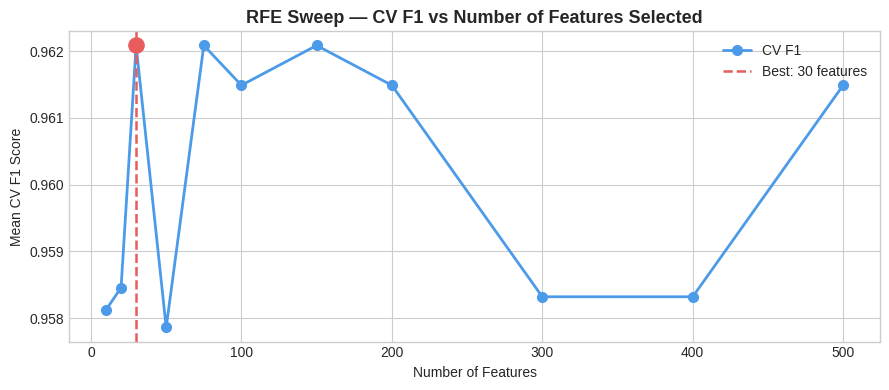

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(sweep_df['n_features'], sweep_df['cv_f1'],
        marker='o', color='#4C9BE8', linewidth=2, markersize=7, label='CV F1')
ax.axvline(best_n, color='#E85C5C', linestyle='--', linewidth=1.8,
           label=f'Best: {best_n} features')
ax.scatter([best_n], [best_row['cv_f1']], color='#E85C5C', s=120, zorder=5)

ax.set_title('RFE Sweep — CV F1 vs Number of Features Selected', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Mean CV F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Final RFE with Best Feature Count

In [10]:
final_rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=random_seed, n_jobs=-1),
    n_features_to_select=best_n,
    step=rfe_step
)
final_rfe.fit(X_train_scaled, y_train)

X_train_final = final_rfe.transform(X_train_scaled)
X_test_final  = final_rfe.transform(X_test_scaled)

selected_cols = surviving_cols[final_rfe.get_support()]

X_train_df = pd.DataFrame(X_train_final, columns=selected_cols)
X_test_df  = pd.DataFrame(X_test_final,  columns=selected_cols)

print(f'Final feature count : {X_train_df.shape[1]}')
print(f'Training samples    : {X_train_df.shape[0]}')
print(f'Test samples        : {X_test_df.shape[0]}')
print()
print('Selected features (first 10):')
print(selected_cols[:10].tolist())

Final feature count : 30
Training samples    : 285
Test samples        : 72

Selected features (first 10):
['201268_at', '201293_x_at', '202544_at', '202824_s_at', '202868_s_at', '202983_at', '203316_s_at', '204428_s_at', '204641_at', '205307_s_at']


## 7. Save Train and Test Sets

In [11]:
y_train_df = y_train.reset_index(drop=True)
y_test_df  = y_test.reset_index(drop=True)

X_train_df.to_csv(data_dir / 'X_train.csv', index=False)
X_test_df.to_csv( data_dir / 'X_test.csv',  index=False)
y_train_df.to_csv(data_dir / 'y_train.csv', index=False)
y_test_df.to_csv( data_dir / 'y_test.csv',  index=False)

print('Saved:')
print(f'  X_train.csv  {X_train_df.shape}')
print(f'  X_test.csv   {X_test_df.shape}')
print(f'  y_train.csv  {y_train_df.shape}')
print(f'  y_test.csv   {y_test_df.shape}')

Saved:
  X_train.csv  (285, 30)
  X_test.csv   (72, 30)
  y_train.csv  (285,)
  y_test.csv   (72,)


## 8. Summary

In [12]:
original_n  = len(gene_cols)
after_step1 = original_n - len(zero_var_cols)
after_step2 = after_step1 - len(high_null_cols)

print(f'Original probes              : {original_n:>7,}')
print(f'After step 1 (zero-var)      : {after_step1:>7,}   (-{len(zero_var_cols):,})')
print(f'After step 2 (>90% null)     : {after_step2:>7,}   (-{len(high_null_cols):,})')
print(f'After step 3 (VT)            : {n_after:>7,}   (-{after_step2 - n_after:,})')
print(f'After step 4 (RFE)           : {best_n:>7,}   (-{n_after - best_n:,})')
print(f'Features kept                : {best_n / original_n * 100:.2f}% of original')
print()
print(f'Training samples : {X_train_df.shape[0]}')
print(f'Test samples     : {X_test_df.shape[0]}')

Original probes              :  22,277
After step 1 (zero-var)      :  22,277   (-0)
After step 2 (>90% null)     :  22,277   (-0)
After step 3 (VT)            :  22,277   (-0)
After step 4 (RFE)           :      30   (-22,247)
Features kept                : 0.13% of original

Training samples : 285
Test samples     : 72
